In [ ]:
import os
import random
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from torchvision.transforms import v2

# Reproducibility
torch.manual_seed(67)
np.random.seed(67)
random.seed(67)

sns.set_palette("husl")
plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (8, 8),
    "axes.formatter.use_mathtext": True,
})

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"CUDA version: {torch.version.cuda}")

torch.backends.cudnn.benchmark = True

Using cuda device
Is CUDA supported by this system? True
Current CUDA device name: NVIDIA GeForce RTX 3090
CUDA version: 13.0


In [ ]:
# Dataset paths (Pascal VOC 2007)
DATA_DIR = Path("data/VOC2007")
IMAGE_DIR = DATA_DIR / "JPEGImages"
ANNOT_DIR = DATA_DIR / "Annotations"
SPLIT_DIR = DATA_DIR / "ImageSets" / "Main"

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
class_to_idx = {name: i for i, name in enumerate(VOC_CLASSES)}
idx_to_class = {i: name for name, i in class_to_idx.items()}


def read_split(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip().split()[0] for line in f if line.strip()]

c:\Users\danib\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def parse_annotation(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        difficult = obj.find("difficult")
        if difficult is not None and int(difficult.text) == 1:
            continue

        name = obj.find("name").text.lower().strip()
        if name not in class_to_idx:
            continue

        box = obj.find("bndbox")
        xmin = float(box.find("xmin").text) - 1.0
        ymin = float(box.find("ymin").text) - 1.0
        xmax = float(box.find("xmax").text) - 1.0
        ymax = float(box.find("ymax").text) - 1.0

        if xmax <= xmin or ymax <= ymin:
            continue

        objects.append({"label": class_to_idx[name], "box": [xmin, ymin, xmax, ymax]})

    return width, height, objects

In [ ]:
train_ids = read_split(SPLIT_DIR / "train.txt")
val_ids = read_split(SPLIT_DIR / "val.txt")

print(f"Train images: {len(train_ids)}")
print(f"Val images: {len(val_ids)}")
print(f"Classes: {len(VOC_CLASSES)}")

assert IMAGE_DIR.exists() and ANNOT_DIR.exists(), "VOC2007 folders not found. Check DATA_DIR path."

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects', 'major_class'],
        num_rows: 5717
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects', 'major_class'],
        num_rows: 5823
    })
})
{'image_id': 0, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x442 at 0x1A6574CC980>, 'width': 500, 'height': 442, 'objects': {'id': [0, 1], 'area': [139194, 16113], 'bbox': [[53.0, 87.0, 471.0, 420.0], [158.0, 44.0, 289.0, 167.0]], 'category': [12, 14]}, 'major_class': 12}


In [ ]:
def show_image_with_boxes(image_id: str):
    image = Image.open(IMAGE_DIR / f"{image_id}.jpg").convert("RGB")
    _, _, objects = parse_annotation(ANNOT_DIR / f"{image_id}.xml")

    plt.imshow(image)
    ax = plt.gca()
    for obj in objects:
        x_min, y_min, x_max, y_max = obj["box"]
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)
        ax.text(
            x_min,
            y_min,
            idx_to_class[obj["label"]],
            fontsize=10,
            color="white",
            bbox=dict(facecolor="red", alpha=0.5),
        )

    plt.axis("off")
    plt.show()

12
14


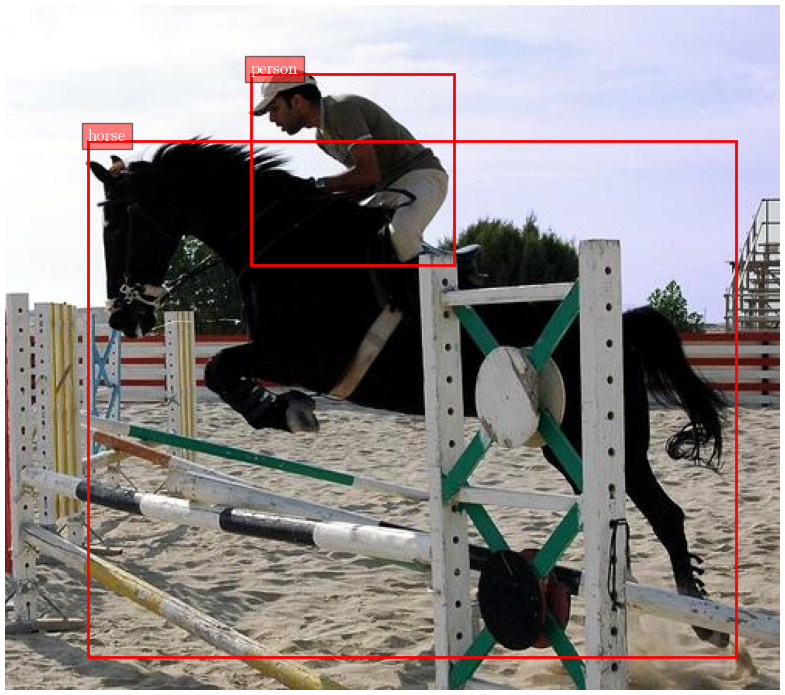

In [ ]:
from torch.utils.data import DataLoader


class VOCObjectDataset(torch.utils.data.Dataset):
    """Each item corresponds to a single object instance from an image."""

    def __init__(self, image_ids, image_dir, annot_dir, image_size=128, transforms=None):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.image_size = image_size
        self.transforms = transforms

        self.items = []
        for image_id in self.image_ids:
            xml_path = self.annot_dir / f"{image_id}.xml"
            if not xml_path.exists():
                continue
            width, height, objects = parse_annotation(xml_path)
            for obj in objects:
                self.items.append({
                    "image_id": image_id,
                    "width": width,
                    "height": height,
                    "label": obj["label"],
                    "box": obj["box"],
                })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image_path = self.image_dir / f"{item['image_id']}.jpg"
        image = Image.open(image_path).convert("RGB")

        # Resize image and scale bounding box accordingly
        if self.image_size is not None:
            image = image.resize((self.image_size, self.image_size), Image.BILINEAR)

        sx = self.image_size / item["width"]
        sy = self.image_size / item["height"]
        x_min, y_min, x_max, y_max = item["box"]
        box = torch.tensor([x_min * sx, y_min * sy, x_max * sx, y_max * sy], dtype=torch.float32)

        # Clamp boxes to image bounds
        box[0::2] = box[0::2].clamp(0, self.image_size - 1)
        box[1::2] = box[1::2].clamp(0, self.image_size - 1)

        if self.transforms is not None:
            image = self.transforms(image)
        else:
            image = v2.ToImage()(image)
            image = v2.ToDtype(torch.float32, scale=True)(image)

        label = torch.tensor(item["label"], dtype=torch.long)
        return image, label, box


def collate_fn(batch):
    images, labels, boxes = zip(*batch)
    return torch.stack(images), torch.stack(labels), torch.stack(boxes)

In [ ]:
# Image size and normalization
IMAGE_SIZE = 128
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tfms = v2.Compose([
    v2.ToImage(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

val_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

train_dataset = VOCObjectDataset(train_ids, IMAGE_DIR, ANNOT_DIR, image_size=IMAGE_SIZE, transforms=train_tfms)
val_dataset = VOCObjectDataset(val_ids, IMAGE_DIR, ANNOT_DIR, image_size=IMAGE_SIZE, transforms=val_tfms)

print(f"Train objects: {len(train_dataset)}")
print(f"Val objects: {len(val_dataset)}")

batch_size = 64
num_workers = 0
pin_memory = device == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

Train dataset size: 5717
Val dataset size: 5823
Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
Sample example keys: dict_keys(['image_id', 'image', 'width', 'height', 'objects', 'major_class'])
Sample example: {'image_id': 0, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x442 at 0x1A6575A79D0>, 'width': 500, 'height': 442, 'objects': {'id': [0, 1], 'area': [139194, 16113], 'bbox': [[53.0, 87.0, 471.0, 420.0], [158.0, 44.0, 289.0, 167.0]], 'category': [12, 14]}, 'major_class': 12}


In [ ]:
# Visualize a random training image with all GT boxes
sample_id = random.choice(train_ids)
show_image_with_boxes(sample_id)

In [ ]:
# Training hyperparameters
num_epochs = 15
learning_rate = 1e-3
weight_decay = 5e-4

In [ ]:
def normalize_boxes(boxes, image_size):
    return boxes / (image_size - 1)


def denormalize_boxes(boxes, image_size):
    return boxes * (image_size - 1)


def box_iou(boxes1, boxes2):
    """IoU for pairs of boxes (N x 4)."""
    x1 = torch.max(boxes1[:, 0], boxes2[:, 0])
    y1 = torch.max(boxes1[:, 1], boxes2[:, 1])
    x2 = torch.min(boxes1[:, 2], boxes2[:, 2])
    y2 = torch.min(boxes1[:, 3], boxes2[:, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)
    union = area1 + area2 - inter + 1e-6
    return inter / union

11
11
11


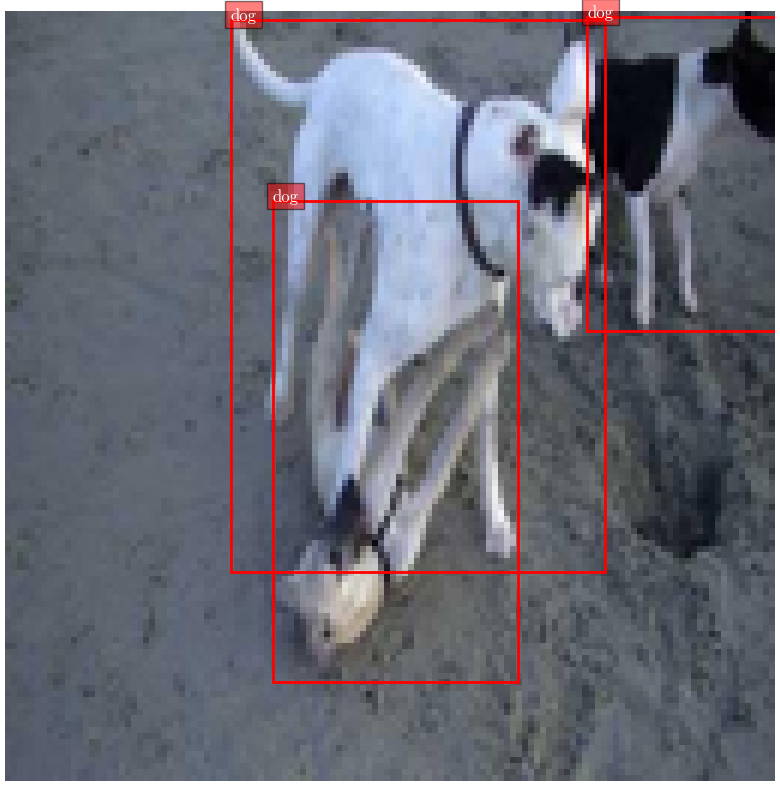

In [ ]:
# Sanity check a batch
images, labels, boxes = next(iter(train_loader))
print(images.shape, labels.shape, boxes.shape)

In [ ]:
def evaluate(model, dataloader, criterion_cls, criterion_box, device):
    model.eval()
    total_loss = 0.0
    total_cls = 0.0
    total_box = 0.0
    total_correct = 0
    total_iou = 0.0
    total = 0

    with torch.no_grad():
        for images, labels, boxes in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            boxes = boxes.to(device)

            class_logits, bbox_pred = model(images)
            bbox_pred = torch.sigmoid(bbox_pred)

            target_boxes = normalize_boxes(boxes, IMAGE_SIZE)
            cls_loss = criterion_cls(class_logits, labels)
            box_loss = criterion_box(bbox_pred, target_boxes)
            loss = cls_loss + box_loss

            total_loss += loss.item()
            total_cls += cls_loss.item()
            total_box += box_loss.item()

            preds = class_logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()

            pred_boxes = denormalize_boxes(bbox_pred, IMAGE_SIZE)
            total_iou += box_iou(pred_boxes, boxes).sum().item()

            total += labels.size(0)

    avg_loss = total_loss / max(1, len(dataloader))
    avg_cls = total_cls / max(1, len(dataloader))
    avg_box = total_box / max(1, len(dataloader))
    acc = total_correct / max(1, total)
    miou = total_iou / max(1, total)
    return avg_loss, avg_cls, avg_box, acc, miou

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion_cls, criterion_box, device):
    model.train()
    running_loss = 0.0
    running_cls = 0.0
    running_box = 0.0

    for images, labels, boxes in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        boxes = boxes.to(device)

        class_logits, bbox_pred = model(images)
        bbox_pred = torch.sigmoid(bbox_pred)
        target_boxes = normalize_boxes(boxes, IMAGE_SIZE)

        cls_loss = criterion_cls(class_logits, labels)
        box_loss = criterion_box(bbox_pred, target_boxes)
        loss = cls_loss + box_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_cls += cls_loss.item()
        running_box += box_loss.item()

    avg_loss = running_loss / max(1, len(dataloader))
    avg_cls = running_cls / max(1, len(dataloader))
    avg_box = running_box / max(1, len(dataloader))
    return avg_loss, avg_cls, avg_box


def train_model(model, train_loader, val_loader, optimizer, criterion_cls, criterion_box, device, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_miou": [],
    }

    for epoch in range(num_epochs):
        train_loss, train_cls, train_box = train_one_epoch(
            model, train_loader, optimizer, criterion_cls, criterion_box, device
        )
        val_loss, val_cls, val_box, val_acc, val_miou = evaluate(
            model, val_loader, criterion_cls, criterion_box, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_miou"].append(val_miou)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train: total={train_loss:.4f}, cls={train_cls:.4f}, box={train_box:.4f} | "
            f"Val: total={val_loss:.4f}, cls={val_cls:.4f}, box={val_box:.4f}, acc={val_acc:.3f}, mIoU={val_miou:.3f}"
        )

    return history

In [ ]:
def plot_history(history):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["val_acc"], label="val acc")
    plt.plot(history["val_miou"], label="val mIoU")
    plt.title("Metrics")
    plt.legend()
    plt.show()

In [ ]:
torch.set_float32_matmul_precision("high")

In [17]:
# CNN implementation (custom detector)
import torch.nn as nn
import torch.nn.functional as F

class MyCNNDetector(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(MyCNNDetector, self).__init__()
        self.__conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /2
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /4
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /8
            nn.Conv2d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.4),
            nn.MaxPool2d(kernel_size=2, stride=2)   # /16
        )
        self.__pool = nn.AdaptiveAvgPool2d((4, 4))
        self.__flatten = nn.Flatten()
        self.__shared = nn.Sequential(
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.__cls_head = nn.Linear(256, num_classes)
        self.__bbox_head = nn.Linear(256, 4)

    def forward(self, x):
        features = self.__conv(x)
        pooled = self.__pool(features)
        flat = self.__flatten(pooled)
        shared = self.__shared(flat)
        class_logits = self.__cls_head(shared)
        bbox_pred = self.__bbox_head(shared)
        return class_logits, bbox_pred


In [ ]:
model = MyCNNDetector(num_classes=len(VOC_CLASSES), dropout_rate=0.5).to(device)
criterion_classification = torch.nn.CrossEntropyLoss()
criterion_bbox = torch.nn.SmoothL1Loss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate,
    momentum=0.9,
    weight_decay=weight_decay,
)

In [ ]:
history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion_classification,
    criterion_bbox,
    device,
    num_epochs=num_epochs,
)

plot_history(history)

In [ ]:
val_loss, val_cls, val_box, val_acc, val_miou = evaluate(
    model, val_loader, criterion_classification, criterion_bbox, device
)
print(
    f"Val: total={val_loss:.4f}, cls={val_cls:.4f}, box={val_box:.4f}, acc={val_acc:.3f}, mIoU={val_miou:.3f}"
)

Epoch 1/20 | Train: total=52.6650, cls=5.3149, box=47.3501
Epoch 1/20 | Val: total=45.5906, cls=10.1060, box=35.4846


In [ ]:
train_loss, train_cls, train_box, train_acc, train_miou = evaluate(
    model, train_loader, criterion_classification, criterion_bbox, device
)
print(
    f"Train: total={train_loss:.4f}, cls={train_cls:.4f}, box={train_box:.4f}, acc={train_acc:.3f}, mIoU={train_miou:.3f}"
)

Test: total=25.2453, cls=2.7054, box=22.5400


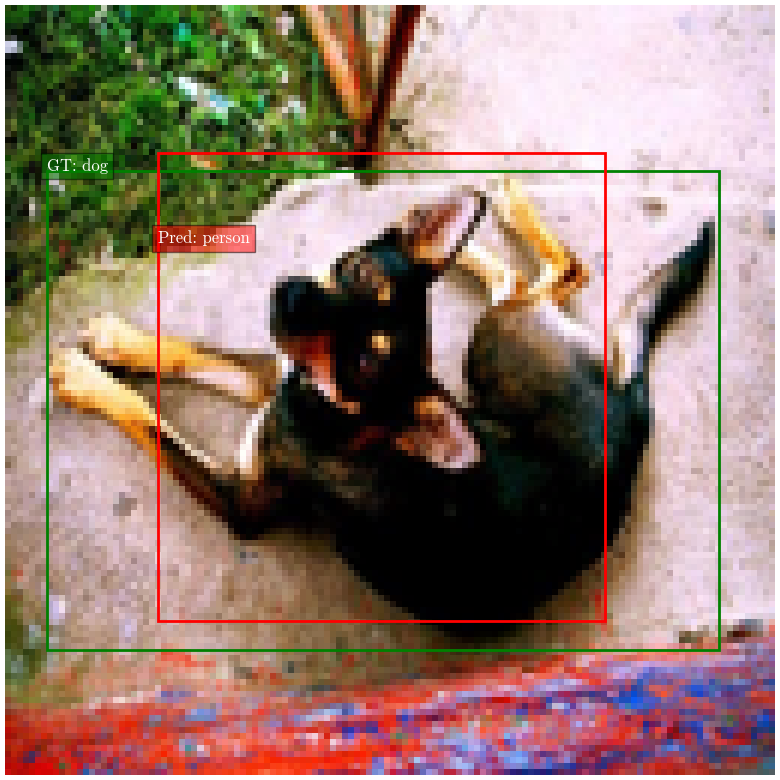

In [ ]:
# Visualize a prediction
idx = random.randint(0, len(val_dataset) - 1)
image, label, box = val_dataset[idx]

model.eval()
with torch.no_grad():
    image_in = image.unsqueeze(0).to(device)
    class_logits, bbox_pred = model(image_in)
    pred_label = class_logits.argmax(dim=1).item()
    pred_box = denormalize_boxes(torch.sigmoid(bbox_pred).cpu(), IMAGE_SIZE).squeeze(0)

# Denormalize image for display
image_np = image.permute(1, 2, 0).cpu().numpy()
image_np = (image_np * np.array(STD)) + np.array(MEAN)
image_np = np.clip(image_np, 0, 1)

plt.imshow(image_np)
ax = plt.gca()

# Ground truth box
x_min, y_min, x_max, y_max = box.numpy()
rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, color="green", linewidth=2)
ax.add_patch(rect)
ax.text(
    x_min,
    y_min,
    f"GT: {idx_to_class[label.item()]}",
    fontsize=10,
    color="white",
    bbox=dict(facecolor="green", alpha=0.5),
)

# Predicted box
px_min, py_min, px_max, py_max = pred_box.numpy()
rect = plt.Rectangle((px_min, py_min), px_max - px_min, py_max - py_min, fill=False, color="red", linewidth=2)
ax.add_patch(rect)
ax.text(
    px_min,
    py_min + 12,
    f"Pred: {idx_to_class[pred_label]}",
    fontsize=10,
    color="white",
    bbox=dict(facecolor="red", alpha=0.5),
)

plt.axis("off")
plt.show()